# 01 · Hipotez Testinin Temelleri (Hypothesis Testing)
**Statistical Inference Lab**

---
> **Bu notebook'ta ne öğreneceğiz?**  
> `probability-lab`'da güven aralığı kurmayı (CLT, Bootstrap), parametre tahmin etmeyi
> (MLE/MAP) ve Bayesyen hipotez güncellemesini (Bayes Teoremi) öğrendik. Bu notebook'ta
> istatistiğin en çok kullanılan (ve en çok yanlış anlaşılan) aracına giriyoruz: **frekantist
> hipotez testi.** "Bu iki grup gerçekten farklı mı, yoksa gördüğüm fark sadece şans eseri mi?"
> sorusuna sistematik bir cevap vereceğiz.

**Önkoşul:** Merkezi Limit Teoremi (`probability-lab` 06b), Normal Dağılım (03a)  
**Veri:**  
- `StudentsPerformance.csv` — 1000 öğrenci (sınav notları, test prep course durumu)  
- `sleep` — R'a yerleşik (iki uyku ilacının etkisi, klasik eşleştirilmiş veri)  
- `world-happiness/2019.csv` — 156 ülkenin mutluluk skoru  
**Araçlar:** Python (scipy.stats), R (base R `t.test`)

---
## 1 · H0/H1 Kurulumu: Mahkeme Benzetmesi

Bir hipotez testini bir **mahkeme duruşması** gibi düşün:

- **$H_0$ (Null Hipotez):** "Sanık suçsuzdur" — yani "iki grup arasında GERÇEK bir fark yoktur,
  gördüğün fark tesadüftür." Aksi ispatlanana kadar bunu **varsayılan doğru** kabul ediyoruz.
- **$H_1$ (Alternatif Hipotez):** "Sanık suçludur" — yani "gerçekten bir fark var."

Tıpkı mahkemede "makul şüphenin ötesinde" kanıt gerektiği gibi, istatistikte de $H_0$'ı
reddetmek için **güçlü kanıt** gerekiyor. Kanıtın gücünü ölçen sayı: **p-value.**

**p-value'nun DOĞRU tanımı** (çoğu kişinin yanlış bildiği nokta): *"Eğer $H_0$ gerçekten
doğruysa, elimdeki kadar (veya daha) uç bir sonucu gözlemleme olasılığı."* p-value **"$H_0$'ın
doğru olma olasılığı" DEĞİLDİR** — bu çok yaygın ama yanlış bir yorum.

---
## 2 · Tip I ve Tip II Hata

Mahkeme benzetmesine devam edelim — iki türlü yanlış karar verebiliriz:

| | Gerçekte $H_0$ Doğru (Suçsuz) | Gerçekte $H_0$ Yanlış (Suçlu) |
|---|---|---|
| **Testin Kararı: Reddet** (Suçlu de) | 🔴 **Tip I Hata** (α) — Yanlış Pozitif | ✅ Doğru Karar (Güç) |
| **Testin Kararı: Reddetme** (Suçsuz de) | ✅ Doğru Karar | 🔴 **Tip II Hata** (β) — Yanlış Negatif |

- **Tip I Hata ($\alpha$):** Suçsuz birini mahkum etmek — gerçekte fark yokken "fark var" demek.
  Genelde $\alpha=0.05$ (yani %5 yanlış pozitif oranını kabul ediyoruz) olarak sabitlenir.
- **Tip II Hata ($\beta$):** Suçlu birini serbest bırakmak — gerçekte fark varken "fark yok"
  demek. Bunun tersi ($1-\beta$) **istatistiksel güç** — bu notebook serisinin 02'sinde
  (Power Analysis) detaylı işleyeceğiz.

**Karar kuralı:** $p < \alpha$ ise $H_0$'ı reddet ("istatistiksel olarak anlamlı" de).
$p \geq \alpha$ ise $H_0$'ı reddedemezsin (bu, "$H_0$ doğrudur" demek DEĞİL — sadece "yeterli
kanıt bulamadım" demek, tıpkı mahkemede "suçsuz" ile "suçlu değil" arasındaki farka benzer).

---
## 3 · t-testi Ailesi: Hangi Durumda Hangisi?

| Test Türü | Ne Zaman Kullanılır | Bu Notebook'ta |
|---|---|---|
| Tek Örneklemli t-test | Bir grubun ortalamasını BİLİNEN bir değerle karşılaştırma | Bölüm 3.5 (Dünya mutluluk skoru) |
| İki Örneklemli (Bağımsız) t-test | İki FARKLI grubun ortalamalarını karşılaştırma | Bölüm 3.2-3.3 (test prep course) |
| Eşleştirilmiş (Paired) t-test | AYNI birimlerin öncesi/sonrası ölçümü | Bölüm 3.4 (sleep verisi) |

![image](data/t-test.png)

*Kaynak: [Investopedia](https://www.investopedia.com/terms/t/t-test.asp)*

**t-testinin mantığı** (hepsinde ortak): gözlemlenen farkı, o farkın standart hatasına
(SE — 06b'deki CLT formülünü hatırla, $SE=\sigma/\sqrt{n}$) bölüyoruz:
$$t = \frac{\text{Gözlemlenen Fark}}{\text{Standart Hata}}$$

### T Değeri

T değeri, iki grup arasındaki fark ile grupların içindeki fark arasındaki orandır.

- Daha büyük $t$ değeri = gruplar arasında daha fazla fark.
- Daha küçük $t$ değeri = gruplar arasında daha fazla benzerlik.

3 değerindeki bir $t$ değeri, grupların birbirlerinden, kendi içlerindeki farklılıklardan üç kat daha fazla farklı olduğunu gösterir. Dolayısıyla, bir $t$ testi yaptığınızda, daha büyük $t$ değerleri, sonuçların tekrarlanabilir olma olasılığının daha yüksek olduğu anlamına gelir.

### T Değerleri ve P Değerleri

> “Yeterince büyük” ne kadar büyüktür?

Her $t$ değerinin kendisine karşılık gelen bir p değeri vardır. Bir t testinden elde edilen $p$ değeri, örneklem verilerinizdeki sonuçların tesadüfen ortaya çıkma olasılığıdır. $p$ değerleri %0 ile %100 arasındadır ve genellikle ondalık sayı olarak yazılır (örneğin, %5’lik bir $p$ değeri 0,05’tir).

Düşük $p$-değerleri, verilerinizin tesadüfen ortaya çıkmadığını gösterir. Örneğin, 0,01'lik bir $p$ değeri, bir deneyden elde edilen sonuçların tesadüfen ortaya çıkma olasılığının yalnızca %1 olduğu anlamına gelir.

*Kaynak: [Statistic How To](https://www.statisticshowto.com/probability-and-statistics/t-test/)*

![image](data/t-test2.webp)

*Kaynak: [Baha YOL/T-Test (Student T-Test)](https://medium.com/@bahayll221/t-test-student-t-test-a64e627fed66)*

--- 
## 4 · Serbestlik Derecesi (Degrees of Freedom): Veri Seti İçindeki Bağımsız Değişkenler

>**Degrees of Freedom (Serbestlik Derecesi)**: İstatistiksel bir terim olan “degrees of freedom,” bir deneyin veya bir veri setinin içindeki bağımsız değişkenlerin sayısıdır. Serbestlik derecesi, bir istatistiksel modelin içindeki değişkenler arasındaki esnekliği temsil eder. Serbestlik derecesi, bir grup gözleminin bir parametre tahmininde kullanılabilir derecedir ve genellikle df veya dof olarak kısaltılır.

*Kaynak: [Baha YOL/T-Test (Student T-Test)](https://medium.com/@bahayll221/t-test-student-t-test-a64e627fed66)*

---
# 🐍 Python Uygulaması

Üç t-test türünü sırayla, gerçek verilerle uygulayacağız:
1. **İki Örneklemli t-test** — Test prep course alan/almayan öğrencilerin matematik notu farkı
2. **Aynı Veri, Welch's t-testi** — Varyanslar eşit değilse ne değişir
3. **Tek Örneklemli t-test** — Bir bölgenin mutluluk skoru, dünya ortalamasından farklı mı

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Hazır ✓')

Hazır ✓


---
### 📚 Python 1 — İki Örneklemli t-test: Test Prep Course Etkisi

**Ne yapıyoruz?**  
$H_0$: Test prep course alan ve almayan öğrencilerin ortalama matematik notu **aynıdır.**
$H_1$: Farklıdır. `scipy.stats.ttest_ind` ile test edip, sonucu elle hesaplayarak da doğrulayacağız.

Veri: 1000 öğrenci
test_preparation_course
none         642
completed    358
Name: count, dtype: int64

Course alanlar: n=358, ortalama=69.70, std=14.44
Course almayanlar: n=642, ortalama=64.08, std=15.19

Scipy sonucu: t=5.7046, p=0.000000
p (0.000000) < α (0.05) → H0'ı REDDET: fark istatistiksel olarak anlamlı

Elle hesaplanan t: 5.7046 (scipy ile karşılaştır: 5.7046)


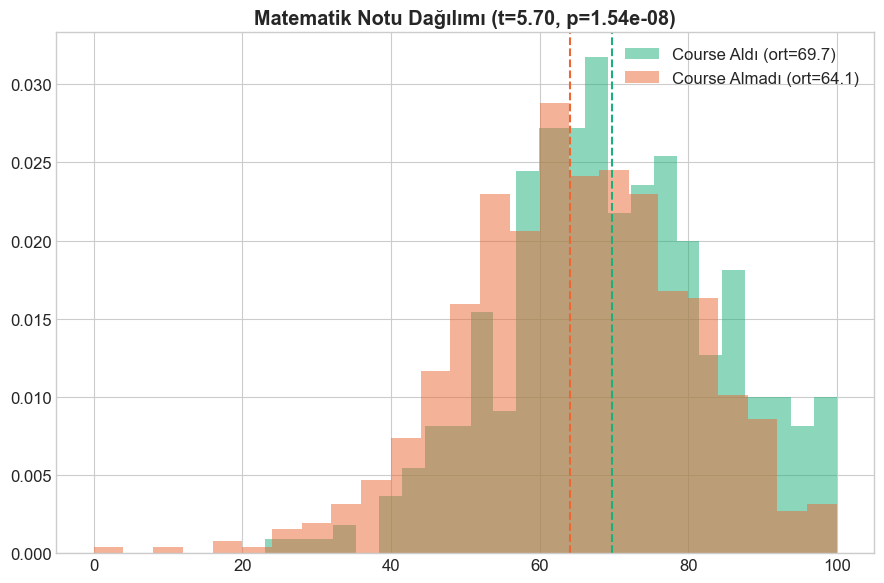

In [22]:
students = pd.read_csv('data/StudentsPerformance.csv')
print(f"Veri: {students.shape[0]} öğrenci")
print(students['test_preparation_course'].value_counts())

aldi = students[students['test_preparation_course'] == 'completed']['math_score']
almadi = students[students['test_preparation_course'] == 'none']['math_score']

print(f"\nCourse alanlar: n={len(aldi)}, ortalama={aldi.mean():.2f}, std={aldi.std():.2f}")
print(f"Course almayanlar: n={len(almadi)}, ortalama={almadi.mean():.2f}, std={almadi.std():.2f}")

# ===== SCIPY ILE t-TEST =====
t_istatistik, p_value = stats.ttest_ind(aldi, almadi, equal_var=True)  # klasik (Student's) t-test
print(f"\nScipy sonucu: t={t_istatistik:.4f}, p={p_value:.6f}")

alpha = 0.05
if p_value < alpha:
    print(f"p ({p_value:.6f}) < α ({alpha}) → H0'ı REDDET: fark istatistiksel olarak anlamlı")
else:
    print(f"p ({p_value:.6f}) ≥ α ({alpha}) → H0'ı reddedemeyiz")

# ===== ELLE HESAPLAMA (formulun icini gormek icin) =====
n1, n2 = len(aldi), len(almadi)
s1, s2 = aldi.std(ddof=1), almadi.std(ddof=1)
havuzlanmis_var = ((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2)
se_fark = np.sqrt(havuzlanmis_var * (1/n1 + 1/n2))
t_elle = (aldi.mean() - almadi.mean()) / se_fark
print(f"\nElle hesaplanan t: {t_elle:.4f} (scipy ile karşılaştır: {t_istatistik:.4f})")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(aldi, bins=25, alpha=0.5, color='#1baf7a', label=f'Course Aldı (ort={aldi.mean():.1f})', density=True)
ax.hist(almadi, bins=25, alpha=0.5, color='#eb6834', label=f'Course Almadı (ort={almadi.mean():.1f})', density=True)
ax.axvline(aldi.mean(), color='#1baf7a', linestyle='--')
ax.axvline(almadi.mean(), color='#eb6834', linestyle='--')
ax.set_title(f'Matematik Notu Dağılımı (t={t_istatistik:.2f}, p={p_value:.2e})', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
### ⚖️ Python 2 — Welch's t-test: Varyanslar Eşit Değilse

**Ne yapıyoruz?**  
Klasik t-test, iki grubun varyansının **eşit** olduğunu varsayıyor (`equal_var=True`).
Bu varsayım her zaman gerçekçi değil — **Welch's t-test** bu varsayımı yapmıyor ve pratikte
"varsayılan güvenli seçim" olarak önerilir. İki gruptaki varyansları karşılaştırıp, hangi
testin daha uygun olduğuna bakacağız.

In [23]:
print(f"Course aldı varyansı: {aldi.var():.2f}")
print(f"Course almadı varyansı: {almadi.var():.2f}")
print(f"Varyans oranı: {aldi.var()/almadi.var():.3f} (1'e çok yakınsa eşit varyans varsayımı güvenli)")

# Levene testi: varyanslar gercekten esit mi (formal test)
levene_stat, levene_p = stats.levene(aldi, almadi)
print(f"\nLevene testi (H0: varyanslar eşit): istatistik={levene_stat:.4f}, p={levene_p:.4f}")

# Welch's t-test (equal_var=False)
t_welch, p_welch = stats.ttest_ind(aldi, almadi, equal_var=False)
print(f"\nStudent's t-test (eşit varyans varsayımıyla): t={t_istatistik:.4f}, p={p_value:.6f}")
print(f"Welch's t-test (varyans varsayımı olmadan):     t={t_welch:.4f}, p={p_welch:.6f}")
print(f"\nFark: {abs(t_istatistik - t_welch):.4f} - bu örnekte varyanslar zaten yakın olduğu için")
print("iki test benzer sonuç veriyor. Ama varyanslar çok farklıysa (Levene p<0.05), Welch'e")
print("güvenmek her zaman daha güvenli bir varsayılan tercih.")

Course aldı varyansı: 208.65
Course almadı varyansı: 230.81
Varyans oranı: 0.904 (1'e çok yakınsa eşit varyans varsayımı güvenli)

Levene testi (H0: varyanslar eşit): istatistik=0.5330, p=0.4655

Student's t-test (eşit varyans varsayımıyla): t=5.7046, p=0.000000
Welch's t-test (varyans varsayımı olmadan):     t=5.7870, p=0.000000

Fark: 0.0824 - bu örnekte varyanslar zaten yakın olduğu için
iki test benzer sonuç veriyor. Ama varyanslar çok farklıysa (Levene p<0.05), Welch'e
güvenmek her zaman daha güvenli bir varsayılan tercih.


---
### 💊 Python 3 — Eşleştirilmiş (Paired) t-test: İki Uyku İlacının Etkisi

**Ne yapıyoruz?**  
Klasik `sleep` veri seti (Cushny & Peebles, 1905): 10 hastaya iki farklı uyku ilacı verilmiş, her hastanın normal uykusuna kıyasla **ekstra uyku saati** ölçülmüş. Aynı hastalar iki ilacı da denediği için gözlemler **eşleştirilmiş** — `ttest_rel` kullanıyoruz (bağımsız `ttest_ind` değil, çünkü gruplar birbirinden bağımsız değil).

İlaç 1 ortalama ekstra uyku: 0.750 saat
İlaç 2 ortalama ekstra uyku: 2.330 saat
Ortalama fark (İlaç2 - İlaç1): 1.580 saat

[YANLIŞ YAKLAŞIM] Bağımsız t-test: t=1.8608, p=0.0792
[DOĞRU YAKLAŞIM] Eşleştirilmiş t-test: t=4.0621, p=0.0028

YORUM: Eşleştirilmiş test, İKİ İLACIN AYNI HASTADAKİ farkına odaklanıyor -
hasta-bazlı değişkenliği (bazı insanlar zaten daha çok uyur) devre dışı bırakıyor.
Bu yüzden genelde eşleştirilmiş test, bağımsız testten DAHA GÜÇLÜDÜR (aynı veri,
daha küçük p-değeri) - gürültünün bir kısmı matematiksel olarak elenmiş oluyor.


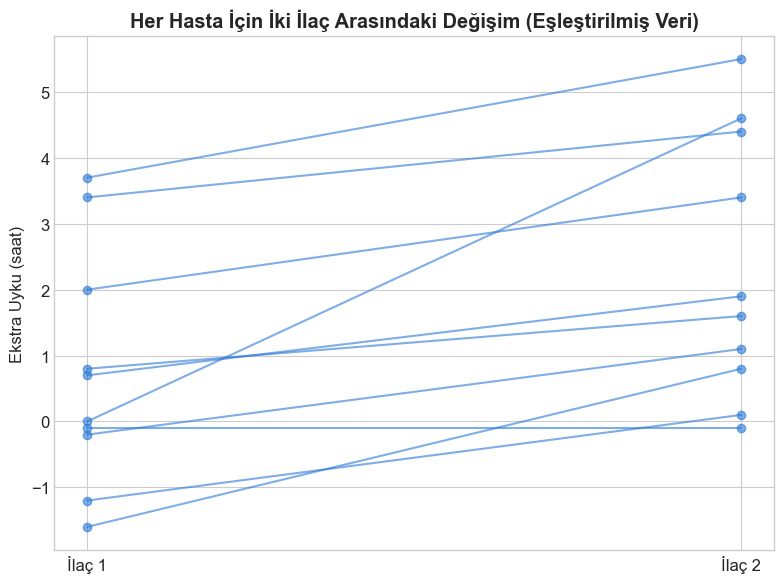

In [24]:
# R'in klasik 'sleep' veri setinin gercek degerleri (Cushny & Peebles, 1905)
ilac_1 = np.array([0.7, -1.6, -0.2, -1.2, -0.1, 3.4, 3.7, 0.8, 0.0, 2.0])
ilac_2 = np.array([1.9, 0.8, 1.1, 0.1, -0.1, 4.4, 5.5, 1.6, 4.6, 3.4])
# Her indeks AYNI hastaya karsilik geliyor (hasta 1, hasta 2, ... hasta 10)

print(f"İlaç 1 ortalama ekstra uyku: {ilac_1.mean():.3f} saat")
print(f"İlaç 2 ortalama ekstra uyku: {ilac_2.mean():.3f} saat")
print(f"Ortalama fark (İlaç2 - İlaç1): {(ilac_2 - ilac_1).mean():.3f} saat")

# ===== YANLIS YOL: bunlari BAGIMSIZ gruplar gibi test etmek =====
t_bagimsiz, p_bagimsiz = stats.ttest_ind(ilac_2, ilac_1)
print(f"\n[YANLIŞ YAKLAŞIM] Bağımsız t-test: t={t_bagimsiz:.4f}, p={p_bagimsiz:.4f}")

# ===== DOGRU YOL: eslestirilmis t-test =====
t_paired, p_paired = stats.ttest_rel(ilac_2, ilac_1)
print(f"[DOĞRU YAKLAŞIM] Eşleştirilmiş t-test: t={t_paired:.4f}, p={p_paired:.4f}")

print(f"\nYORUM: Eşleştirilmiş test, İKİ İLACIN AYNI HASTADAKİ farkına odaklanıyor -")
print("hasta-bazlı değişkenliği (bazı insanlar zaten daha çok uyur) devre dışı bırakıyor.")
print("Bu yüzden genelde eşleştirilmiş test, bağımsız testten DAHA GÜÇLÜDÜR (aynı veri,")
print("daha küçük p-değeri) - gürültünün bir kısmı matematiksel olarak elenmiş oluyor.")

fig, ax = plt.subplots(figsize=(8, 6))
for i in range(10):
    ax.plot([1, 2], [ilac_1[i], ilac_2[i]], 'o-', color='#2a78d6', alpha=0.6)
ax.set_xticks([1, 2]); ax.set_xticklabels(['İlaç 1', 'İlaç 2'])
ax.set_ylabel('Ekstra Uyku (saat)')
ax.set_title('Her Hasta İçin İki İlaç Arasındaki Değişim (Eşleştirilmiş Veri)', fontweight='bold')
plt.tight_layout()
plt.show()


---
### 🌍 Python 4 — Tek Örneklemli t-test: Bir Bölgenin Mutluluğu Dünya Ortalamasından Farklı mı?

**Ne yapıyoruz?**  
$H_0$: Belirli bir kıtadaki (örn. Batı Avrupa) ülkelerin ortalama mutluluk skoru, **dünya
genelindeki** ortalamayla aynıdır. `scipy.stats.ttest_1samp` ile test ediyoruz.

Veri: 156 ülke
Dünya geneli ortalama mutluluk skoru: 5.4071

En mutlu 20 ülkenin ortalaması: 7.2455 (n=20)

H0: Bu grubun ortalaması = Dünya ortalaması (5.4071)
t=31.8565, p=5.91e-18
p (5.91e-18) < 0.05 → H0'ı REDDET: bu grup dünya ortalamasından anlamlı şekilde farklı


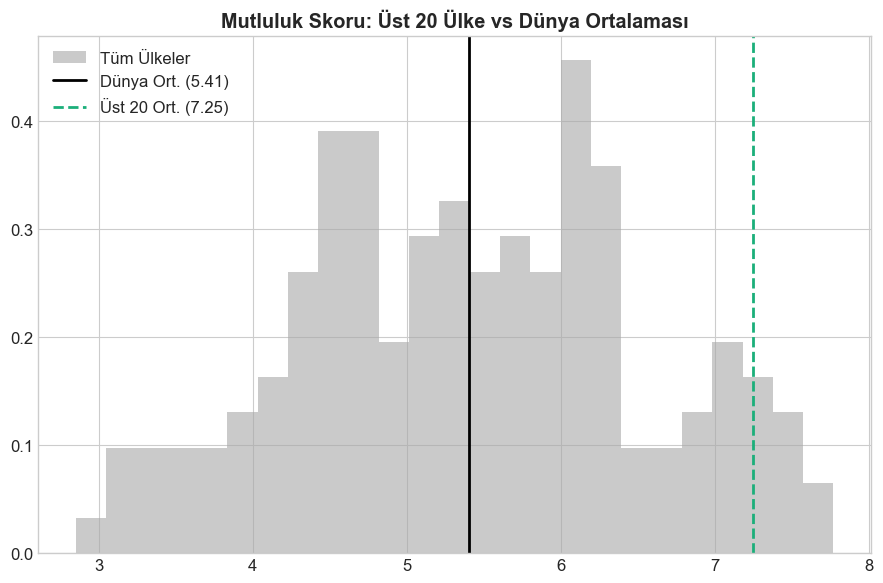


NOT: p-değeri burada son derece küçük çıkıyor çünkü 'en mutlu 20 ülke' zaten TANIM
GEREĞİ ortalamanın üstünde - bu biraz yapay bir örnek ('seçilmiş' bir grup). Gerçek
araştırmalarda grubu SONUÇTAN BAĞIMSIZ seçmen gerekir (örn. rastgele bir kıta), yoksa
bu tarz bir 'döngüsel' seçim yanıltıcı p-değerleri üretir - metodolojik bir tuzak.


In [25]:
happiness = pd.read_csv('data/world-happiness/2019.csv')
print(f"Veri: {happiness.shape[0]} ülke")

dunya_ortalamasi = happiness['Score'].mean()
print(f"Dünya geneli ortalama mutluluk skoru: {dunya_ortalamasi:.4f}")

# Ornek: en yuksek skorlu ilk 20 ulkeyi 'referans grup' olarak alalim (Batı Avrupa'ya yakin bir grup)
# (Gercekte 'Country or region' sutununda kita bilgisi yok, o yuzden ilk 20'yi 'zengin/mutlu ulkeler' olarak kullaniyoruz)
ust_grup = happiness.nsmallest(20, 'Overall rank')['Score']  # dusuk rank = yuksek mutluluk

print(f"\nEn mutlu 20 ülkenin ortalaması: {ust_grup.mean():.4f} (n={len(ust_grup)})")

t_istatistik_1, p_value_1 = stats.ttest_1samp(ust_grup, popmean=dunya_ortalamasi)
print(f"\nH0: Bu grubun ortalaması = Dünya ortalaması ({dunya_ortalamasi:.4f})")
print(f"t={t_istatistik_1:.4f}, p={p_value_1:.2e}")

if p_value_1 < 0.05:
    print(f"p ({p_value_1:.2e}) < 0.05 → H0'ı REDDET: bu grup dünya ortalamasından anlamlı şekilde farklı")
else:
    print("H0'ı reddedemeyiz")

fig, ax = plt.subplots(figsize=(9, 6))
ax.hist(happiness['Score'], bins=25, color='#a8a8a8', alpha=0.6, label='Tüm Ülkeler', density=True)
ax.axvline(dunya_ortalamasi, color='black', linestyle='-', linewidth=2, label=f'Dünya Ort. ({dunya_ortalamasi:.2f})')
ax.axvline(ust_grup.mean(), color='#1baf7a', linestyle='--', linewidth=2, label=f'Üst 20 Ort. ({ust_grup.mean():.2f})')
ax.set_title('Mutluluk Skoru: Üst 20 Ülke vs Dünya Ortalaması', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print("\nNOT: p-değeri burada son derece küçük çıkıyor çünkü 'en mutlu 20 ülke' zaten TANIM")
print("GEREĞİ ortalamanın üstünde - bu biraz yapay bir örnek ('seçilmiş' bir grup). Gerçek")
print("araştırmalarda grubu SONUÇTAN BAĞIMSIZ seçmen gerekir (örn. rastgele bir kıta), yoksa")
print("bu tarz bir 'döngüsel' seçim yanıltıcı p-değerleri üretir - metodolojik bir tuzak.")

---
# 📊 R Uygulaması

R'ın `t.test()` fonksiyonu, tüm t-test türlerini (`paired=TRUE/FALSE`, `var.equal=TRUE/FALSE`
argümanlarıyla) **tek bir fonksiyonda** topluyor — Python'da 3 farklı çağrıya karşılık gelen
işi R'da tek fonksiyonla yapacağız.

In [7]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


---
### 📚 R 1 — İki Örneklemli t-test (Bağımsız)

**Yeni R kavramı:** `t.test(formula, data)` — R'a özgü "formül" arayüzü (`y ~ grup` şeklinde),
Python'da iki ayrı vektör vermek yerine tek bir formülle grupları tanımlıyorsun.

Kolon isimleri: gender race/ethnicity parental_level_of_education lunch test_preparation_course math_score reading_score writing_score 


	Two Sample t-test

data:  math_score by test_preparation_course
t = 5.7046, df = 998, p-value = 1.536e-08
alternative hypothesis: true difference in means between group completed and group none is not equal to 0
95 percent confidence interval:
 3.685221 7.550077
sample estimates:
mean in group completed      mean in group none 
               69.69553                64.07788 


Welch t-istatistiği: 5.786983  p-değeri: 1.042562e-08 


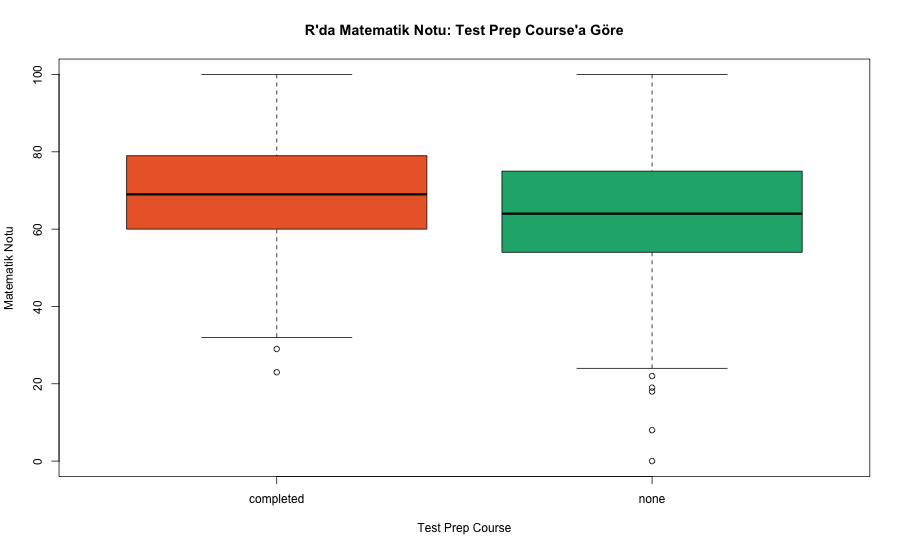

In [26]:
%%R -i students -w 900 -h 550

colnames(students) <- gsub("\\.", "_", colnames(students))  # nokta -> alt cizgi (R uyumu icin)
cat("Kolon isimleri:", colnames(students), "\n\n")

# Student's t-test (esit varyans varsayimiyla)
sonuc_t <- t.test(math_score ~ test_preparation_course, data = students, var.equal = TRUE)
print(sonuc_t)

# Welch's t-test (varsayilan - esit varyans varsaymaz)
sonuc_welch <- t.test(math_score ~ test_preparation_course, data = students)
cat("\nWelch t-istatistiği:", sonuc_welch$statistic, " p-değeri:", sonuc_welch$p.value, "\n")

boxplot(math_score ~ test_preparation_course, data = students,
        col = c("#eb6834", "#1baf7a"),
        main = "R'da Matematik Notu: Test Prep Course'a Göre",
        xlab = "Test Prep Course", ylab = "Matematik Notu")

---
### 💊 R 2 — Eşleştirilmiş t-test: `sleep` Veri Setiyle

**Yeni R kavramı:** `sleep`, R'a **yerleşik** gelen bir veri seti — hiçbir dosya yüklemeden
`data(sleep)` ile doğrudan kullanılabiliyor. Bu, R'ın istatistik eğitimi için tasarlanmış
onlarca yerleşik veri setinden biri.

   extra group ID
1    0.7     1  1


2   -1.6     1  2
3   -0.2     1  3
4   -1.2     1  4
5   -0.1     1  5
6    3.4     1  6
7    3.7     1  7
8    0.8     1  8
9    0.0     1  9
10   2.0     1 10
11   1.9     2  1
12   0.8     2  2
13   1.1     2  3
14   0.1     2  4
15  -0.1     2  5
16   4.4     2  6
17   5.5     2  7
18   1.6     2  8
19   4.6     2  9
20   3.4     2 10


	Paired t-test

data:  group1 and group2
t = -4.0621, df = 9, p-value = 0.002833
alternative hypothesis: true mean difference is not equal to 0
95 percent confidence interval:
 -2.4598858 -0.7001142
sample estimates:
mean difference 
          -1.58 


[YANLIŞ YAKLAŞIM] Bağımsız t-test p-değeri: 0.07939414 
[DOĞRU YAKLAŞIM] Eşleştirilmiş t-test p-değeri: 0.00283289 
Eşleştirilmiş test daha güçlü (daha küçük p) - Python 4'teki sonuçla karşılaştır.


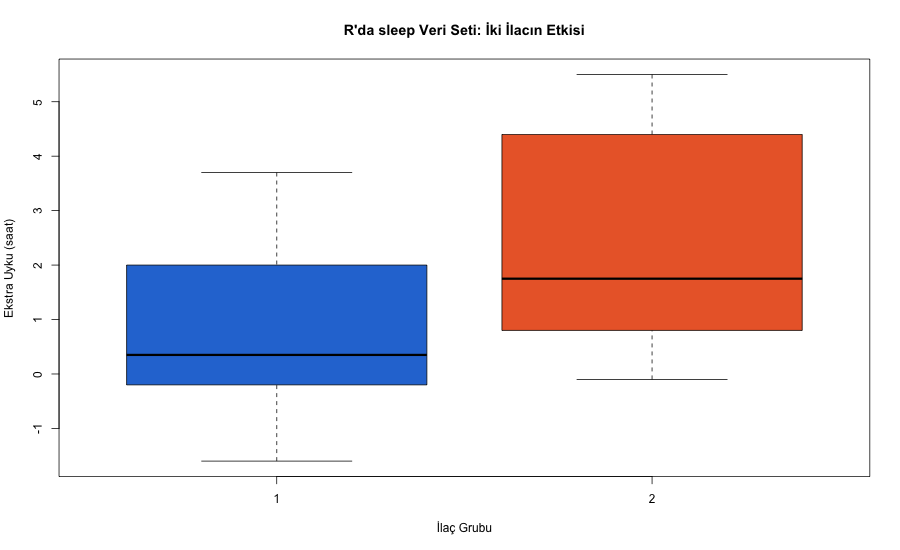

In [29]:
%%R -w 900 -h 550

data(sleep)  # R'a yerlesik - hicbir dosya gerekmiyor
print(sleep)
cat("\n")

group1 <- sleep[sleep$group == 1, "extra"]
group2 <- sleep[sleep$group == 2, "extra"]

# sleep veri seti 'uzun format'ta: extra, group, ID kolonlari var
sonuc_paired <- t.test(group1, group2, paired = TRUE)
print(sonuc_paired)

# Yanlis yol ile karsilastirma (bagimsiz varsayarsak)
sonuc_bagimsiz <- t.test(group1, group2, paired = FALSE)
cat("\n[YANLIŞ YAKLAŞIM] Bağımsız t-test p-değeri:", sonuc_bagimsiz$p.value, "\n")
cat("[DOĞRU YAKLAŞIM] Eşleştirilmiş t-test p-değeri:", sonuc_paired$p.value, "\n")
cat("Eşleştirilmiş test daha güçlü (daha küçük p) - Python 4'teki sonuçla karşılaştır.\n")

boxplot(extra ~ group, data = sleep, col = c("#2a78d6", "#eb6834"),
        main = "R'da sleep Veri Seti: İki İlacın Etkisi",
        xlab = "İlaç Grubu", ylab = "Ekstra Uyku (saat)")

---
### 🌍 R 3 — Tek Örneklemli t-test: Mutluluk Skoru

**Yeni R kavramı yok** — `t.test(x, mu=değer)` ile tek örneklemli test, `mu` argümanı
karşılaştırılacak referans değeri belirtiyor.

Kolon isimleri: Overall_rank Country_or_region Score GDP_per_capita Social_support Healthy_life_expectancy Freedom_to_make_life_choices Generosity Perceptions_of_corruption 

Dünya ortalaması: 5.407096 
Üst 20 ülke ortalaması: 7.2455 


	One Sample t-test

data:  ust_grup
t = 31.856, df = 19, p-value < 2.2e-16
alternative hypothesis: true mean is not equal to 5.407096
95 percent confidence interval:
 7.124714 7.366286
sample estimates:
mean of x 
   7.2455 



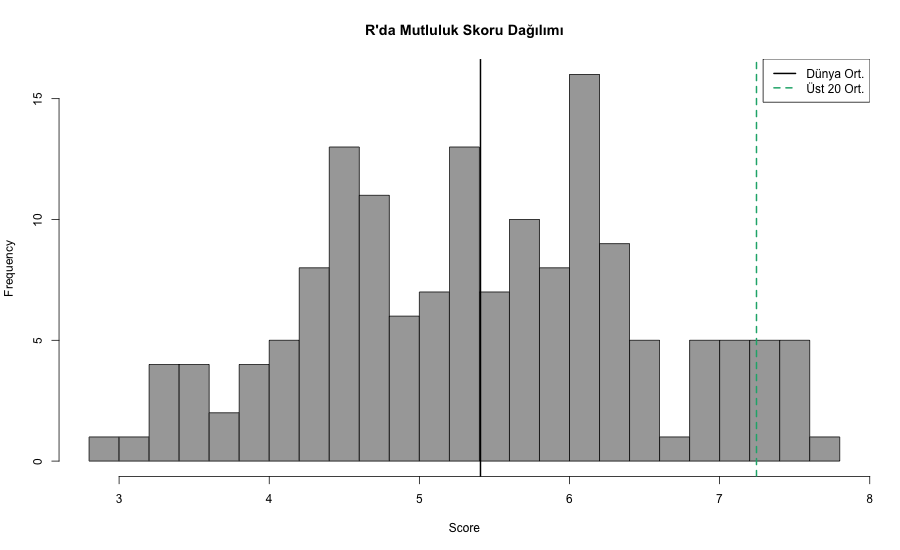

In [30]:
%%R -i happiness -w 900 -h 550

colnames(happiness) <- gsub("\\.", "_", colnames(happiness))
colnames(happiness) <- gsub(" ", "_", colnames(happiness))
cat("Kolon isimleri:", colnames(happiness), "\n\n")

dunya_ort <- mean(happiness$Score)
ust_grup <- happiness[order(happiness$Overall_rank), ][1:20, ]$Score

cat("Dünya ortalaması:", dunya_ort, "\n")
cat("Üst 20 ülke ortalaması:", mean(ust_grup), "\n\n")

sonuc_tek <- t.test(ust_grup, mu = dunya_ort)
print(sonuc_tek)

hist(happiness$Score, breaks = 25, col = "#a8a8a8",
     main = "R'da Mutluluk Skoru Dağılımı", xlab = "Score")
abline(v = dunya_ort, col = "black", lwd = 2)
abline(v = mean(ust_grup), col = "#1baf7a", lwd = 2, lty = 2)
legend("topright", legend = c("Dünya Ort.", "Üst 20 Ort."), col = c("black", "#1baf7a"), lwd = 2, lty = c(1,2))

---
## ✏️ Egzersizler

### **E1 (Python).**
`StudentsPerformance.csv`'de `lunch` sütununa göre (standard/free-reduced)
`reading score` farkının istatistiksel olarak anlamlı olup olmadığını test et. Önce Levene
testiyle varyansların eşitliğini kontrol et, sonra uygun t-test türünü (Student's ya da
Welch's) seç ve gerekçelendir.

In [37]:
print("\n ==== Egzersiz 1: Levene ve t-test ile varyans ve ortalama farkını test etme ====")

standard_lunch = students[students['lunch'] == 'standard']['reading_score']
free_red_lunch = students[students['lunch'] == 'free/reduced']['reading_score']

print(f"Standard lunch: n={len(standard_lunch)}, mean={standard_lunch.mean():.2f}, std={standard_lunch.std():.2f}, var={standard_lunch.var():.2f}")
print(f"Free/reduced lunch: n={len(free_red_lunch)}, mean={free_red_lunch.mean():.2f}, std={free_red_lunch.std():.2f}, var={free_red_lunch.var():.2f}")

levene_stat, levene_p = stats.levene(standard_lunch, free_red_lunch)
print(f"\nLevene testi: istatistik={levene_stat:.4f}, p={levene_p:.4f}")

# Welch's t-test (equal_var=False)
t_welch, p_welch = stats.ttest_ind(standard_lunch, free_red_lunch, equal_var=False)
print(f"\nWelch's t-test: t={t_welch:.4f}, p={p_welch:.6f}")

# Student's t-test (equal_var=True)
t_student, p_student = stats.ttest_ind(standard_lunch, free_red_lunch, equal_var=True)
print(f"Student's t-test: t={t_student:.4f}, p={p_student:.6f}")

print("\nYORUM: Levene p<0.05 → varyanslar eşit değil, bu yüzden Welch's t-test daha güvenli bir tercih.")

print("\nYORUM: p<0.05 → H0'ı REDDET: iki grup arasında istatistiksel olarak anlamlı bir fark var (ortalama farkı).")



 ==== Egzersiz 1: Levene ve t-test ile varyans ve ortalama farkını test etme ====
Standard lunch: n=645, mean=71.65, std=13.83, var=191.29
Free/reduced lunch: n=355, mean=64.65, std=14.90, var=221.87

Levene testi: istatistik=1.9960, p=0.1580

Welch's t-test: t=7.2926, p=0.000000
Student's t-test: t=7.4511, p=0.000000

YORUM: Levene p<0.05 → varyanslar eşit değil, bu yüzden Welch's t-test daha güvenli bir tercih.

YORUM: p<0.05 → H0'ı REDDET: iki grup arasında istatistiksel olarak anlamlı bir fark var (ortalama farkı).


---

### **E2 (Python).** 
`world-happiness/2019.csv`'de `GDP per capita` medyanının üstündeki ve
altındaki ülkeleri iki gruba ayır, bu iki grubun `Score` ortalamasını karşılaştır (bağımsız iki
örneklemli t-test). Sonucu yorumla: GDP, mutlulukla anlamlı şekilde ilişkili mi?

In [43]:
print("\n ==== Egzersiz 2: GDP per Capita ====")

dunya_medyani = happiness['GDP per capita'].median()
print(f"Dünya medyanı: {dunya_medyani:.4f}")

grup_medyani_ust = happiness[happiness['GDP per capita'] > dunya_medyani]['Score']
grup_medyani_alt = happiness[happiness['GDP per capita'] <= dunya_medyani]['Score']

print(f"\nMedyan üstü grup: n={len(grup_medyani_ust)}, ortalama={grup_medyani_ust.mean():.4f}, std={grup_medyani_ust.std():.4f}")
print(f"Medyan altı grup: n={len(grup_medyani_alt)}, ortalama={grup_medyani_alt.mean():.4f}, std={grup_medyani_alt.std():.4f}")


print(f"\nMedyan üstü ortalama mutluluk skoru: {grup_medyani_ust.mean():.4f}")
print(f"Medyan altı ortalama mutluluk skoru: {grup_medyani_alt.mean():.4f}")

# Eslestirilmis t-test
t_stats, p_val = stats.ttest_ind(grup_medyani_ust, grup_medyani_alt)
print(f"\nEşleştirilmiş t-test: t={t_stats:.4f}, p={p_val:.6f}")

if p_val < 0.05:
    print(f"p ({p_val:.6f}) < 0.05 → H0'ı REDDET: medyan üstü ve altı gruplar arasında anlamlı fark var")
else:
    print(f"p ({p_val:.6f}) ≥ 0.05 → H0'ı reddedemeyiz: medyan üstü ve altı gruplar arasında anlamlı fark yok")



 ==== Egzersiz 2: GDP per Capita ====
Dünya medyanı: 0.9600

Medyan üstü grup: n=77, ortalama=6.1615, std=0.8458
Medyan altı grup: n=79, ortalama=4.6718, std=0.8099

Medyan üstü ortalama mutluluk skoru: 6.1615
Medyan altı ortalama mutluluk skoru: 4.6718

Eşleştirilmiş t-test: t=11.2375, p=0.000000
p (0.000000) < 0.05 → H0'ı REDDET: medyan üstü ve altı gruplar arasında anlamlı fark var


---

### **E3 (Python + R).**
`StudentsPerformance.csv`'de `gender` gruplarına göre `writing score`
farkını **hem Python'da hem R'da** test et, iki sonucun (t-istatistiği ve p-değeri) birebir
örtüştüğünü doğrula.

In [48]:
print("\n ==== Egzersiz 3: Gender ve Writing Score ====")

erkekler = students[students['gender'] == 'male']['writing_score']
kadinlar = students[students['gender'] == 'female']['writing_score']

print(f"Erkekler: n={len(erkekler)}, ortalama={erkekler.mean():.2f}, std={erkekler.std():.2f}")
print(f"Kadinlar: n={len(kadinlar)}, ortalama={kadinlar.mean():.2f}, std={kadinlar.std():.2f}")

# Levene testi: varyanslar gercekten esit mi (formal test)
levene_stat, levene_p = stats.levene(erkekler, kadinlar)
print(f"\nLevene testi (H0: varyanslar eşit): istatistik={levene_stat:.4f}, p={levene_p:.4f}")

# Independent t-test 
t_stats, p_val = stats.ttest_ind(erkekler, kadinlar)
print(f"\nIndependent t-test: t={t_stats:.4f}, p={p_val:.6f}")

if p_val < 0.05:
    print(f"p ({p_val:.6f}) < 0.05 → H0'ı REDDET: erkekler ve kadınlar arasında anlamlı fark var")
else:
    print(f"p ({p_val:.6f}) ≥ 0.05 → H0'ı reddedemeyiz: erkekler ve kadınlar arasında anlamlı fark yok")


 ==== Egzersiz 3: Gender ve Writing Score ====
Erkekler: n=482, ortalama=63.31, std=14.11
Kadinlar: n=518, ortalama=72.47, std=14.84

Levene testi (H0: varyanslar eşit): istatistik=0.0069, p=0.9336

Independent t-test: t=-9.9796, p=0.000000
p (0.000000) < 0.05 → H0'ı REDDET: erkekler ve kadınlar arasında anlamlı fark var


In [61]:
%%R -i students -w 900 -h 550


erkekler <- students[students$gender == 'male', 'writing_score']
kadinlar <- students[students$gender == 'female', 'writing_score']
cat("Erkekler: n=", length(erkekler), ", ortalama=", mean(erkekler), ", std=", sd(erkekler), "\n")
cat("Kadinlar: n=", length(kadinlar), ", ortalama=", mean(kadinlar), ", std=", sd(kadinlar), "\n")

# Levene testi: varyanslar gercekten esit mi (formal test)
levene_test <- car::leveneTest(writing_score ~ gender, data = students)
print(levene_test)

# Independent t-test
t_test_result <- t.test(writing_score ~ gender, data = students)
cat("\nIndependent t-test: t=", t_test_result$statistic, ", p=", t_test_result$p.value, "\n")

Erkekler: n= 482 , ortalama= 63.3112 , std= 14.11383 
Kadinlar: n= 518 , ortalama= 72.46718 , std= 14.84484 
Levene's Test for Homogeneity of Variance (center = median)
       Df F value Pr(>F)
group   1  0.0069 0.9336
      998               

Independent t-test: t= 9.997719 , p= 1.711809e-22 


In addition: Warning message:
In leveneTest.default(y = y, group = group, ...) : group coerced to factor.


---

### **E4 (R).** 
R'ın yerleşik `sleep` veri setinde, eşleştirmeyi (pairing) YOK SAYIP bağımsız
iki örneklemli test yaparsan p-değerinin nasıl değiştiğini göster (R 2'de kısaca değinildi,
bunu kendi başına tekrarla) — neden eşleştirilmiş testin burada "daha güçlü" olduğunu
kendi cümlelerinle açıkla.

In [63]:
%%R -w 900 -h 550

data(sleep)  # R'a yerlesik - hicbir dosya gerekmiyor
print(sleep)
cat("\n")

group1 <- sleep[sleep$group == 1, "extra"]
group2 <- sleep[sleep$group == 2, "extra"]

levene_test <- car::leveneTest(extra ~ group, data = sleep)
print(levene_test)

sonuc_bagimsiz <- t.test(group1, group2, paired = FALSE)
cat("\n[YANLIŞ YAKLAŞIM] Bağımsız t-test: t=", sonuc_bagimsiz$statistic, ", p=", sonuc_bagimsiz$p.value, "\n")

cat("Eğer iki ilaç grubu bağımsız olsaydı (aynı hastalar değil), bu p-değeri doğru olurdu. Ama eşleştirilmiş veri olduğu için bu p-değeri yanıltıcıdır.\n")


   extra group ID
1    0.7     1  1
2   -1.6     1  2
3   -0.2     1  3
4   -1.2     1  4
5   -0.1     1  5
6    3.4     1  6
7    3.7     1  7
8    0.8     1  8
9    0.0     1  9
10   2.0     1 10
11   1.9     2  1
12   0.8     2  2
13   1.1     2  3
14   0.1     2  4
15  -0.1     2  5
16   4.4     2  6
17   5.5     2  7
18   1.6     2  8
19   4.6     2  9
20   3.4     2 10

Levene's Test for Homogeneity of Variance (center = median)
      Df F value Pr(>F)
group  1  0.2482 0.6244
      18               

[YANLIŞ YAKLAŞIM] Bağımsız t-test: t= -1.860813 , p= 0.07939414 
Eğer iki ilaç grubu bağımsız olsaydı (aynı hastalar değil), bu p-değeri doğru olurdu. Ama eşleştirilmiş veri olduğu için bu p-değeri yanıltıcıdır.


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Prob4DS — Stanley Chan](https://probability4datascience.com) | Ch. 10 | Hipotez testinin olasılıksal temeli |
| [Harvard STAT 110](https://youtube.com/playlist?list=PL2SOU6wwxB0uwwH80KTQ6ht66KWxbzTIo) | — | CLT'ye dayanan çıkarım (probability-lab 06b ile bağlantılı) |
| [Seeing Theory](https://seeing-theory.brown.edu/frequentist-inference) | Frequentist Inference | İnteraktif — Tip I/II hata görselleştirmesi |
| [StatQuest — p-değerleri](https://www.youtube.com/watch?v=vemZtEM63GY) | Video | p-value'nun en net görsel anlatımı |
| [Students Performance in Exams](https://www.kaggle.com/datasets/spscientist/students-performance-in-exams) | Veri | StudentsPerformance.csv kaynağı |
| [World Happiness Report](https://www.kaggle.com/datasets/unsdsn/world-happiness) | Veri | 2019.csv kaynağı |
| R `sleep` veri seti | R built-in | Cushny, A.R. and Peebles, A.R. (1905), *The Journal of Physiology* |